# BIRD Mini-Dev 500: EX@1, Oracle@3, and Oracle@5 Evaluation

This notebook compares the same four controlled conditions on the **same 500 official BIRD Mini-Dev examples**:

1. Base model without BIRD evidence
2. Base model with BIRD evidence
3. SFT model without BIRD evidence
4. SFT model with BIRD evidence

For every question, each condition produces five ranked SQL candidates:

- **Candidate 1** is greedy decoding and is used for **EX@1**. This preserves comparability with the previous single-output evaluation.
- **Candidates 2–5** are reproducible stochastic samples.
- **Oracle@3** is correct when at least one of candidates 1–3 has the same execution result as the Gold SQL.
- **Oracle@5** is correct when at least one of candidates 1–5 has the same execution result as the Gold SQL.

The notebook retains the original four-way Base/SFT × Evidence design, resumable CSV outputs, official BIRD execution semantics, per-difficulty/database summaries, paired tests, and plots. It additionally saves every candidate and its execution result.

> Oracle@K is an upper bound on what a perfect selector could recover from K candidates. It is not deployable accuracy by itself; a ranking or verification stage is needed to turn the gap between EX@1 and Oracle@K into real gains.

> Runtime note: the full four-way run evaluates 2,000 prompts and 10,000 SQL candidates. The four sampled candidates are generated together for speed, but the run will still be several times more expensive than the original EX@1-only notebook.

Before running: in Colab, select **Runtime → Change runtime type → GPU (A100 recommended)**.


## 0. Evaluation Protocol

- Use the classic **BIRD Mini-Dev 500**, not the later Mini-Dev V2 with 780 examples.
- Load `mini_dev_sqlite` from `birdsql/bird_mini_dev` at the pinned revision `f65faf4ae3b638c1fa6df1d3370c8d92c8366301`.
- Use the complete official SQLite package, `minidev_0703.zip`.
- Match official EX semantics: execute predicted and Gold SQL independently, convert returned rows to sets, and compare the sets for equality.
- Candidate 1 uses greedy decoding; candidates 2–5 use seeded sampling with the same decoding settings in all four conditions.
- Report **EX@1**, **Oracle@3**, and **Oracle@5**. Since the candidate sets are nested, the notebook checks `EX@1 <= Oracle@3 <= Oracle@5` for every example.
- Mini-Dev 500 is a public development set. It is suitable as a checkpoint-independent evaluation set only until its results are used to tune the model, prompt, or decoding settings.

Official resources:

- [BIRD Mini-Dev GitHub](https://github.com/bird-bench/mini_dev)
- [BIRD Mini-Dev Hugging Face](https://huggingface.co/datasets/birdsql/bird_mini_dev)
- [Official EX evaluator](https://github.com/bird-bench/mini_dev/blob/main/evaluation/evaluation_ex.py)


## 1. Install Dependencies


In [1]:
!pip -q install -U \
    "transformers>=4.48" \
    "peft>=0.14" \
    "accelerate>=1.2" \
    "bitsandbytes>=0.45" \
    "datasets>=3.2" \
    "gdown>=5.2" \
    "sqlglot>=26.0" \
    "scipy>=1.11" \
    pandas matplotlib seaborn tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 123.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.8/741.8 kB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 127.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 131.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Imports, Random Seeds, and Google Drive


In [2]:
import gc
import hashlib
import json
import math
import os
import random
import re
import shutil
import sqlite3
import statistics
import time
import warnings
import zipfile
from pathlib import Path
from urllib.parse import quote

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sqlglot
import torch
from datasets import load_dataset
from IPython.display import display
from peft import PeftConfig, PeftModel
from scipy.stats import binomtest
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    set_seed,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 160)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("No GPU was detected. In Colab, select Runtime → Change runtime type → GPU.")

print("GPU:", torch.cuda.get_device_name(0))
print("CUDA:", torch.version.cuda)
print("BF16 supported:", torch.cuda.is_bf16_supported())

from google.colab import drive
drive.mount("/content/drive")


GPU: NVIDIA A100-SXM4-40GB
CUDA: 12.8
BF16 supported: True
Mounted at /content/drive


## 3. Configuration

The paths below match this project's Google Drive layout.

- Raw Mini-Dev data and the Hugging Face cache are stored under `data/`.
- The fixed 500-example snapshot is stored under `processed/`.
- New multi-candidate outputs are stored under `results/minidev500_ex1_oracle3_oracle5_four_way/`, so the earlier single-candidate results are not overwritten.
- The SFT adapter is loaded from the configured training run's `final_adapter/`.
- Candidate 1 is greedy. Candidates 2–5 use `temperature=0.7` and `top_p=0.95` with a deterministic per-example seed.

To evaluate a checkpoint instead of `final_adapter`, change only `SFT_ADAPTER_DIR`.


In [3]:
# ========================= PROJECT LAYOUT =========================
PROJECT_ROOT = Path("/content/drive/MyDrive/bird-text2sql-sft")

DATA_DIR = PROJECT_ROOT / "data"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
PROCESSED_DIR = PROJECT_ROOT / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

TRAINING_RUN_DIR = (
    PROJECT_ROOT
    / "training"
    / "qwen2.5-coder-7b-bf16-lora-sft-v2-filtered-mixed-evidence-lr2e-5-len8192"
)
CHECKPOINTS_DIR = TRAINING_RUN_DIR / "checkpoints"
SFT_ADAPTER_DIR = TRAINING_RUN_DIR / "final_adapter"
TRAINING_LOGS_DIR = TRAINING_RUN_DIR / "logs"

# Use a new directory so the previous EX@1-only results remain untouched.
PROJECT_DIR = RESULTS_DIR / "minidev500_ex1_oracle3_oracle5_four_way"

for directory in [
    DATA_DIR,
    NOTEBOOKS_DIR,
    PROCESSED_DIR,
    RESULTS_DIR,
    PROJECT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)
# ==================================================================

BASE_MODEL_ID = "Qwen/Qwen2.5-Coder-7B-Instruct"

# Official dataset revision and database package
HF_DATASET_ID = "birdsql/bird_mini_dev"
HF_REVISION = "f65faf4ae3b638c1fa6df1d3370c8d92c8366301"
HF_SPLIT = "mini_dev_sqlite"
OFFICIAL_DB_GOOGLE_DRIVE_ID = "13VLWIwpw5E3d5DUkMvzw7hvHE67a4XkG"

# Persist all downloaded BIRD data and Hugging Face files under data/.
LOCAL_DATA_ROOT = DATA_DIR / "bird_minidev500"
LOCAL_ZIP_PATH = LOCAL_DATA_ROOT / "minidev_0703.zip"
LOCAL_EXTRACT_DIR = LOCAL_DATA_ROOT / "extracted"
HF_CACHE_DIR = DATA_DIR / "hf_cache"

# Identical loading/context settings for Base and SFT.
LOAD_IN_4BIT = False
MAX_INPUT_TOKENS = 8192
MAX_NEW_TOKENS = 256
SQL_TIMEOUT_SECONDS = 30.0

# Candidate protocol: rank 1 is greedy; ranks 2-5 are sampled together.
NUM_CANDIDATES = 5
ORACLE_K_VALUES = (1, 3, 5)
NUM_SAMPLED_CANDIDATES = NUM_CANDIDATES - 1
SAMPLING_TEMPERATURE = 0.7
SAMPLING_TOP_P = 0.95

assert NUM_CANDIDATES == max(ORACLE_K_VALUES)
assert ORACLE_K_VALUES[0] == 1
assert tuple(sorted(ORACLE_K_VALUES)) == ORACLE_K_VALUES

# Experiment controls
RUN_BASELINE = True
RUN_SFT = True
RESUME = True
FORCE_RESTART = False  # Set True only when intentionally deleting this new run's partial CSVs.
SAVE_EVERY = 5
DEBUG_LIMIT = None      # Use 5 for a smoke test; restore None for the full 500 examples.

PROMPT_VERSION = "bird_schema_evidence_ablation_chat_v2"
EVIDENCE_CONDITIONS = [False, True]

EXPERIMENTS = {
    "baseline_no_evidence": {"model_type": "baseline", "use_evidence": False},
    "baseline_with_evidence": {"model_type": "baseline", "use_evidence": True},
    "sft_no_evidence": {"model_type": "sft", "use_evidence": False},
    "sft_with_evidence": {"model_type": "sft", "use_evidence": True},
}

print("Project root:", PROJECT_ROOT)
print("SFT adapter directory:", SFT_ADAPTER_DIR)
print("Evaluation results directory:", PROJECT_DIR)
print("Candidate protocol: 1 greedy +", NUM_SAMPLED_CANDIDATES, "sampled")


Project root: /content/drive/MyDrive/bird-text2sql-sft
SFT adapter directory: /content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-sft-v2-filtered-mixed-evidence-lr2e-5-len8192/final_adapter
Evaluation results directory: /content/drive/MyDrive/bird-text2sql-sft/results/minidev500_ex1_oracle3_oracle5_four_way
Candidate protocol: 1 greedy + 4 sampled


### 3.1 Verify the Project Layout and Adapter Path

The next cell verifies the configured `final_adapter` directory. If it is missing, the notebook searches only inside this training run, including its `checkpoints/` directory, instead of scanning the entire Google Drive.


In [4]:
def find_adapter_candidates(root=TRAINING_RUN_DIR, max_results=30):
    candidates = []
    if not root.exists():
        return candidates

    for config_path in root.rglob("adapter_config.json"):
        folder = config_path.parent
        if (folder / "adapter_model.safetensors").exists() or (folder / "adapter_model.bin").exists():
            candidates.append(folder)
            if len(candidates) >= max_results:
                break
    return candidates


adapter_required = SFT_ADAPTER_DIR / "adapter_config.json"
if RUN_SFT and not adapter_required.exists():
    print("The configured final_adapter directory is invalid:", SFT_ADAPTER_DIR)
    print("\nCandidate adapter directories found in the configured training run:")
    candidates = find_adapter_candidates()
    if candidates:
        for p in candidates:
            print(" -", p)
    else:
        print("(No directory containing adapter_config.json and adapter weights was found.)")
    raise FileNotFoundError(
        "Confirm the project layout or update SFT_ADAPTER_DIR in the previous cell, then rerun this cell."
    )

if RUN_SFT:
    peft_config = PeftConfig.from_pretrained(str(SFT_ADAPTER_DIR))
    print("Adapter:", SFT_ADAPTER_DIR)
    print("Adapter recorded base model:", peft_config.base_model_name_or_path)


Adapter: /content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-sft-v2-filtered-mixed-evidence-lr2e-5-len8192/final_adapter
Adapter recorded base model: Qwen/Qwen2.5-Coder-7B-Instruct


## 4. Download and Pin the Mini-Dev 500 Dataset


In [5]:
dataset_dict = load_dataset(
    HF_DATASET_ID,
    revision=HF_REVISION,
    cache_dir=str(HF_CACHE_DIR),
)

if HF_SPLIT not in dataset_dict:
    raise KeyError(f"Could not find split={HF_SPLIT}; available splits: {list(dataset_dict.keys())}")

raw_split = dataset_dict[HF_SPLIT]
print(raw_split)
print("Columns:", raw_split.column_names)


def first_present(example, names, default=None):
    for name in names:
        if name in example and example[name] is not None:
            return example[name]
    return default


records = []
for position, example in enumerate(raw_split):
    gold_sql = first_present(example, ["SQL", "sql", "query", "gold_sql"])
    if gold_sql is None:
        raise KeyError(f"Gold SQL was not found for example {position}. Fields={list(example.keys())}")

    records.append({
        "position": position,
        "source_index": first_present(example, ["index", "idx", "id"], position),
        "db_id": str(first_present(example, ["db_id", "database_id"])),
        "question": str(first_present(example, ["question", "utterance"])),
        "evidence": str(first_present(example, ["evidence", "external_knowledge"], "") or ""),
        "gold_sql": str(gold_sql).strip(),
        "difficulty": str(first_present(example, ["difficulty", "level"], "unknown")).lower(),
    })

eval_df = pd.DataFrame(records)

assert len(eval_df) == 500, f"Expected 500 examples, found {len(eval_df)}"
assert eval_df["db_id"].nunique() == 11, (
    f"Expected 11 databases, found {eval_df['db_id'].nunique()}"
)
assert eval_df["question"].notna().all()
assert eval_df["gold_sql"].str.len().gt(0).all()

dataset_payload = eval_df.to_json(orient="records", force_ascii=False)
DATASET_SHA256 = hashlib.sha256(dataset_payload.encode("utf-8")).hexdigest()

# Store the pinned, normalized 500-example evaluation snapshot under processed/.
snapshot_path = PROCESSED_DIR / "mini_dev_500_snapshot.jsonl"
eval_df.to_json(
    snapshot_path,
    orient="records",
    lines=True,
    force_ascii=False,
)

print("Rows:", len(eval_df))
print("Databases:", eval_df["db_id"].nunique())
print("Dataset SHA256:", DATASET_SHA256)
print("Processed snapshot:", snapshot_path)
display(eval_df.head(3))
display(eval_df["difficulty"].value_counts(dropna=False).rename("count").to_frame())
display(eval_df["db_id"].value_counts().sort_index().rename("count").to_frame())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

Dataset({
    features: ['question_id', 'db_id', 'question', 'evidence', 'SQL', 'difficulty'],
    num_rows: 500
})
Columns: ['question_id', 'db_id', 'question', 'evidence', 'SQL', 'difficulty']
Rows: 500
Databases: 11
Dataset SHA256: c38826f6825c30bd2d3916f30dab8f259e149bf9ca8d2d0bb454d8493105b52c
Processed snapshot: /content/drive/MyDrive/bird-text2sql-sft/processed/mini_dev_500_snapshot.jsonl


,position,source_index,db_id,question,evidence,gold_sql,difficulty
0,0,0,debit_card_specializing,What is the ratio of customers who pay in EUR against customers who pay in CZK?,ratio of customers who pay in EUR against customers who pay in CZK = count(Currency = 'EUR') / count(Currency = 'CZK').,"SELECT CAST(SUM(IIF(Currency = 'EUR', 1, 0)) AS FLOAT) / SUM(IIF(Currency = 'CZK', 1, 0)) AS ratio FROM customers",simple
1,1,1,debit_card_specializing,"In 2012, who had the least consumption in LAM?",Year 2012 can be presented as Between 201201 And 201212; The first 4 strings of the Date values in the yearmonth table can represent year.,"SELECT T1.CustomerID FROM customers AS T1 INNER JOIN yearmonth AS T2 ON T1.CustomerID = T2.CustomerID WHERE T1.Segment = 'LAM' AND SUBSTR(T2.Date, 1, 4) = '...",moderate
2,2,2,debit_card_specializing,What was the average monthly consumption of customers in SME for the year 2013?,Average Monthly consumption = AVG(Consumption) / 12; Year 2013 can be presented as Between 201301 And 201312; The first 4 strings of the Date values in the ...,"SELECT AVG(T2.Consumption) / 12 FROM customers AS T1 INNER JOIN yearmonth AS T2 ON T1.CustomerID = T2.CustomerID WHERE SUBSTR(T2.Date, 1, 4) = '2013' AND T1...",moderate


,count
difficulty,
moderate,250
simple,148
challenging,102


,count
db_id,
california_schools,30
card_games,52
codebase_community,49
debit_card_specializing,30
european_football_2,51
financial,32
formula_1,66
student_club,48
superhero,52


## 5. Download and Extract the Official SQLite Databases


In [6]:
LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

if not LOCAL_ZIP_PATH.exists():
    print("Downloading the database package from the official BIRD Google Drive...")
    downloaded = gdown.download(
        id=OFFICIAL_DB_GOOGLE_DRIVE_ID,
        output=str(LOCAL_ZIP_PATH),
        quiet=False,
    )
    if downloaded is None or not LOCAL_ZIP_PATH.exists():
        raise RuntimeError("The database package download failed. Rerun this cell.")
else:
    print("The archive already exists; skipping download:", LOCAL_ZIP_PATH)

if not zipfile.is_zipfile(LOCAL_ZIP_PATH):
    raise RuntimeError(f"The downloaded file is not a valid ZIP archive: {LOCAL_ZIP_PATH}")

extract_marker = LOCAL_EXTRACT_DIR / ".extraction_complete"
if not extract_marker.exists():
    if LOCAL_EXTRACT_DIR.exists():
        shutil.rmtree(LOCAL_EXTRACT_DIR)
    LOCAL_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    print("Extracting the archive...")
    with zipfile.ZipFile(LOCAL_ZIP_PATH) as zf:
        zf.extractall(LOCAL_EXTRACT_DIR)
    extract_marker.touch()
    print("Extraction completed:", LOCAL_EXTRACT_DIR)
else:
    print("The archive is already extracted; skipping:", LOCAL_EXTRACT_DIR)


The archive already exists; skipping download: /content/drive/MyDrive/bird-text2sql-sft/data/bird_minidev500/minidev_0703.zip
The archive is already extracted; skipping: /content/drive/MyDrive/bird-text2sql-sft/data/bird_minidev500/extracted


## 6. Automatically Locate the 11 Databases and Check Integrity


In [7]:
import shutil
import sqlite3
from pathlib import Path
from urllib.parse import quote

# Requirements:
# 1. eval_df has already been created.
# 2. LOCAL_EXTRACT_DIR points to the extracted Mini-Dev database directory.

assert "eval_df" in globals(), "Run the Mini-Dev dataset loading cell first."
assert "LOCAL_EXTRACT_DIR" in globals(), (
    "Run the database download and extraction cell first."
)
assert LOCAL_EXTRACT_DIR.exists(), (
    f"Database directory does not exist: {LOCAL_EXTRACT_DIR}"
)


def collect_sqlite_files(root: Path):
    """Find SQLite database files under the extracted directory."""
    suffixes = {".sqlite", ".sqlite3", ".db"}

    return sorted(
        path
        for path in root.rglob("*")
        if path.is_file() and path.suffix.lower() in suffixes
    )


def resolve_db_path(db_id: str, candidates):
    """Find the SQLite file corresponding to one BIRD db_id."""

    # Preferred structure: .../<db_id>/<db_id>.sqlite
    preferred = [
        path
        for path in candidates
        if path.stem == db_id and path.parent.name == db_id
    ]
    if preferred:
        return min(preferred, key=lambda path: len(str(path)))

    # Match the filename, such as california_schools.sqlite
    stem_matches = [
        path for path in candidates
        if path.stem == db_id
    ]
    if stem_matches:
        return min(stem_matches, key=lambda path: len(str(path)))

    # Match the parent directory.
    parent_matches = [
        path for path in candidates
        if path.parent.name == db_id
    ]
    if parent_matches:
        return min(parent_matches, key=lambda path: len(str(path)))

    raise FileNotFoundError(
        f"Could not find a SQLite file for db_id={db_id}"
    )


# Step 1: Locate the source databases.
sqlite_files = collect_sqlite_files(LOCAL_EXTRACT_DIR)

print("SQLite-like files found:", len(sqlite_files))

if not sqlite_files:
    raise FileNotFoundError(
        f"No SQLite files were found under {LOCAL_EXTRACT_DIR}"
    )

db_ids = sorted(eval_df["db_id"].dropna().unique())

print("Unique database IDs in Mini-Dev:", len(db_ids))
assert len(db_ids) == 11, (
    f"Expected 11 Mini-Dev databases, but found {len(db_ids)}"
)

SOURCE_DB_PATHS = {
    db_id: resolve_db_path(db_id, sqlite_files)
    for db_id in db_ids
}

print("All source databases were resolved.")


# Step 2: Copy the 11 databases to the local Colab SSD.
LOCAL_DB_CACHE = Path("/content/bird_minidev500_sqlite")
LOCAL_DB_CACHE.mkdir(parents=True, exist_ok=True)

DB_PATHS = {}

for position, db_id in enumerate(db_ids, start=1):
    source_path = SOURCE_DB_PATHS[db_id]

    target_dir = LOCAL_DB_CACHE / db_id
    target_dir.mkdir(parents=True, exist_ok=True)

    target_path = target_dir / source_path.name

    source_size = source_path.stat().st_size
    target_is_complete = (
        target_path.exists()
        and target_path.stat().st_size == source_size
    )

    if target_is_complete:
        status = "cached"
    else:
        shutil.copy2(source_path, target_path)
        status = "copied"

    DB_PATHS[db_id] = target_path

    print(
        f"[{position:02d}/{len(db_ids)}] "
        f"{db_id}: {status} "
        f"({source_size / 1024**2:.2f} MB)"
    )


# Step 3: Perform only a fast database-opening check.
health_rows = []

for db_id, db_path in DB_PATHS.items():
    uri = f"file:{quote(str(db_path.resolve()))}?mode=ro"

    with sqlite3.connect(uri, uri=True, timeout=10) as connection:
        table_count = connection.execute(
            """
            SELECT COUNT(*)
            FROM sqlite_master
            WHERE type = 'table'
              AND name NOT LIKE 'sqlite_%'
            """
        ).fetchone()[0]

    health_rows.append(
        {
            "db_id": db_id,
            "db_path": str(db_path),
            "storage": "Colab local SSD",
            "table_count": table_count,
            "size_mb": round(db_path.stat().st_size / 1024**2, 2),
        }
    )

    print(f"Opened {db_id}: {table_count} tables")


db_health_df = pd.DataFrame(health_rows)

assert len(DB_PATHS) == 11
assert all(path.exists() for path in DB_PATHS.values())
assert db_health_df["table_count"].gt(0).all(), db_health_df

display(db_health_df)

print("DB_PATHS has been created successfully.")
print("All evaluation queries will use the local Colab SSD.")

SQLite-like files found: 22
Unique database IDs in Mini-Dev: 11
All source databases were resolved.
[01/11] california_schools: copied (10.60 MB)
[02/11] card_games: copied (249.69 MB)
[03/11] codebase_community: copied (459.12 MB)
[04/11] debit_card_specializing: copied (33.03 MB)
[05/11] european_football_2: copied (570.06 MB)
[06/11] financial: copied (67.99 MB)
[07/11] formula_1: copied (21.32 MB)
[08/11] student_club: copied (2.52 MB)
[09/11] superhero: copied (0.23 MB)
[10/11] thrombosis_prediction: copied (6.99 MB)
[11/11] toxicology: copied (2.55 MB)
Opened california_schools: 3 tables
Opened card_games: 6 tables
Opened codebase_community: 8 tables
Opened debit_card_specializing: 5 tables
Opened european_football_2: 7 tables
Opened financial: 8 tables
Opened formula_1: 13 tables
Opened student_club: 8 tables
Opened superhero: 10 tables
Opened thrombosis_prediction: 3 tables
Opened toxicology: 4 tables


,db_id,db_path,storage,table_count,size_mb
0,california_schools,/content/bird_minidev500_sqlite/california_schools/california_schools.sqlite,Colab local SSD,3,10.60
1,card_games,/content/bird_minidev500_sqlite/card_games/card_games.sqlite,Colab local SSD,6,249.69
2,codebase_community,/content/bird_minidev500_sqlite/codebase_community/codebase_community.sqlite,Colab local SSD,8,459.12
3,debit_card_specializing,/content/bird_minidev500_sqlite/debit_card_specializing/debit_card_specializing.sqlite,Colab local SSD,5,33.03
4,european_football_2,/content/bird_minidev500_sqlite/european_football_2/european_football_2.sqlite,Colab local SSD,7,570.06
5,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,Colab local SSD,8,67.99
6,formula_1,/content/bird_minidev500_sqlite/formula_1/formula_1.sqlite,Colab local SSD,13,21.32
7,student_club,/content/bird_minidev500_sqlite/student_club/student_club.sqlite,Colab local SSD,8,2.52
8,superhero,/content/bird_minidev500_sqlite/superhero/superhero.sqlite,Colab local SSD,10,0.23
9,thrombosis_prediction,/content/bird_minidev500_sqlite/thrombosis_prediction/thrombosis_prediction.sqlite,Colab local SSD,3,6.99


DB_PATHS has been created successfully.
All evaluation queries will use the local Colab SSD.


In [8]:
assert len(DB_PATHS) == 11
assert all(path.exists() for path in DB_PATHS.values())

print("All 11 databases are ready on the local Colab disk.")

All 11 databases are ready on the local Colab disk.


## 7. Build the Schema and Controlled Evidence Prompts

This is the **only prompt definition** in the notebook. All four conditions call it.

Every prompt includes:

- The SQLite `CREATE TABLE` schema
- The same `External knowledge:` field, containing either the real BIRD evidence or `None`
- The user question
- An explicit instruction to output exactly one SQLite SQL query

Only the contents of the evidence field change between the no-evidence and with-evidence conditions. If your SFT training used a different prompt template, replace `build_messages()` below with the exact version used during training while retaining the explicit `use_evidence` argument.


In [9]:
SCHEMA_CACHE = {}


def get_sqlite_schema(db_path):
    cache_key = str(Path(db_path).resolve())
    if cache_key in SCHEMA_CACHE:
        return SCHEMA_CACHE[cache_key]

    uri = f"file:{quote(cache_key)}?mode=ro"
    with sqlite3.connect(uri, uri=True) as conn:
        rows = conn.execute(
            '''
            SELECT name, sql
            FROM sqlite_master
            WHERE type = 'table'
              AND name NOT LIKE 'sqlite_%'
              AND sql IS NOT NULL
            ORDER BY name
            '''
        ).fetchall()

    schema = "\n\n".join(sql.strip() + ";" for _, sql in rows)
    SCHEMA_CACHE[cache_key] = schema
    return schema


SYSTEM_PROMPT = (
    "You are an expert SQLite developer. "
    "Given a database schema, a question, and optional evidence, "
    "write one valid SQLite query that answers the question. "
    "Return only the SQL query without explanations or Markdown."
)


def build_messages(record, use_evidence):
    schema = get_sqlite_schema(DB_PATHS[record["db_id"]])
    evidence = record.get("evidence", "").strip()
    evidence_block = evidence if (use_evidence and evidence) else "None"

    user_prompt = f'''Database ID:
{record['db_id']}

SQLite schema:
{schema}

External knowledge:
{evidence_block}

Question:
{record['question']}

Write exactly one executable SQLite query that answers the question. Return SQL only.'''

    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]


preview_record = eval_df.iloc[0].to_dict()
print("NO-EVIDENCE PROMPT:")
print(json.dumps(build_messages(preview_record, False), ensure_ascii=False, indent=2))
print("\nWITH-EVIDENCE PROMPT:")
print(json.dumps(build_messages(preview_record, True), ensure_ascii=False, indent=2))

evidence_coverage = eval_df["evidence"].fillna("").str.strip().ne("").mean()
print(f"\nNon-empty BIRD evidence: {evidence_coverage:.1%}")


NO-EVIDENCE PROMPT:
[
  {
    "role": "system",
    "content": "You are an expert SQLite developer. Given a database schema, a question, and optional evidence, write one valid SQLite query that answers the question. Return only the SQL query without explanations or Markdown."
  },
  {
    "role": "user",
    "content": "Database ID:\ndebit_card_specializing\n\nSQLite schema:\nCREATE TABLE customers\n(\n    CustomerID INTEGER UNIQUE     not null\n        primary key,\n    Segment    TEXT null,\n    Currency   TEXT null\n);\n\nCREATE TABLE gasstations\n(\n    GasStationID INTEGER    UNIQUE   not null\n        primary key,\n    ChainID      INTEGER          null,\n    Country      TEXT null,\n    Segment      TEXT null\n);\n\nCREATE TABLE products\n(\n    ProductID   INTEGER   UNIQUE      not null\n        primary key,\n    Description TEXT null\n);\n\nCREATE TABLE \"transactions_1k\"\n(\n    TransactionID INTEGER\n        primary key autoincrement,\n    Date          DATE,\n    Time     

## 8. SQL Extraction, Normalization, and Official EX Semantics


In [10]:
def first_sql_statement(text):
    '''Keep the first SQL statement and ignore semicolons inside quoted strings.'''
    quote_char = None
    i = 0
    while i < len(text):
        ch = text[i]
        if quote_char is None:
            if ch in {"'", '"', '`'}:
                quote_char = ch
            elif ch == ";":
                return text[: i + 1]
        else:
            if ch == quote_char:
                # Two consecutive quote characters in SQL represent an escaped quote
                if i + 1 < len(text) and text[i + 1] == quote_char:
                    i += 1
                else:
                    quote_char = None
        i += 1
    return text


def extract_sql(raw_text):
    text = (raw_text or "").strip()
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.IGNORECASE | re.DOTALL).strip()

    fenced = re.search(
        r"```(?:sql|sqlite)?\s*(.*?)```",
        text,
        flags=re.IGNORECASE | re.DOTALL,
    )
    if fenced:
        text = fenced.group(1).strip()

    start = re.search(r"\b(?:SELECT|WITH)\b", text, flags=re.IGNORECASE)
    if start:
        text = text[start.start():]

    text = first_sql_statement(text).strip()
    text = re.sub(r"\s*(?:<\|im_end\|>|<\|endoftext\|>)\s*$", "", text).strip()
    return text


def normalize_sql(sql):
    if not sql or not sql.strip():
        return ""
    try:
        parsed = sqlglot.parse_one(sql, read="sqlite")
        return parsed.sql(dialect="sqlite", pretty=False, normalize=True).strip().lower()
    except Exception:
        fallback = re.sub(r"\s+", " ", sql.strip().rstrip(";"))
        return fallback.lower()


def execute_read_only(db_path, sql, timeout_seconds=30.0):
    '''Execute a query through a read-only SQLite connection with a progress-handler timeout.'''
    if not sql or not sql.strip():
        return None, 0.0, "empty SQL"

    start_time = time.perf_counter()
    deadline = start_time + timeout_seconds
    uri = f"file:{quote(str(Path(db_path).resolve()))}?mode=ro"
    conn = None
    try:
        conn = sqlite3.connect(uri, uri=True, timeout=timeout_seconds)
        conn.execute("PRAGMA query_only = ON")
        conn.set_progress_handler(lambda: 1 if time.perf_counter() > deadline else 0, 10_000)
        rows = conn.execute(sql).fetchall()
        elapsed = time.perf_counter() - start_time
        return rows, elapsed, ""
    except Exception as exc:
        elapsed = time.perf_counter() - start_time
        message = str(exc)
        if "interrupted" in message.lower() and time.perf_counter() >= deadline:
            message = f"timeout after {timeout_seconds:.1f}s"
        return None, elapsed, message
    finally:
        if conn is not None:
            conn.close()


def official_execution_equal(predicted_rows, gold_rows):
    '''Match the official BIRD Mini-Dev evaluation_ex.py semantics: set(pred) == set(gold).'''
    if predicted_rows is None or gold_rows is None:
        return False
    return set(predicted_rows) == set(gold_rows)


# Run a Gold SQL sanity check to catch an incorrect database package or mapping.
gold_check_rows = []
for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Gold SQL sanity check"):
    result, elapsed, error = execute_read_only(
        DB_PATHS[row["db_id"]],
        row["gold_sql"],
        SQL_TIMEOUT_SECONDS,
    )
    gold_check_rows.append({
        "position": int(row["position"]),
        "gold_valid": result is not None,
        "gold_execution_seconds": elapsed,
        "gold_error": error,
    })

gold_check_df = pd.DataFrame(gold_check_rows)
display(gold_check_df["gold_valid"].value_counts(dropna=False).rename("count").to_frame())

if not gold_check_df["gold_valid"].all():
    display(gold_check_df.loc[~gold_check_df["gold_valid"]].head(20))
    raise RuntimeError(
        "At least one Gold SQL query could not be executed. Check the database package, db_id mapping, and SQLite version."
    )


Gold SQL sanity check:   0%|          | 0/500 [00:00<?, ?it/s]

,count
gold_valid,
True,500


## 9. Model Loading and Five-Candidate Generation

`generate_candidates()` performs two decoding calls per example:

1. One deterministic greedy output for candidate 1 / EX@1.
2. Four seeded stochastic outputs in one batched call for candidates 2–5.

Using a greedy first candidate keeps EX@1 comparable to the original notebook. The per-example seed makes the sampled candidate set reproducible across reruns.


In [11]:
COMPUTE_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16


def make_quantization_config():
    if not LOAD_IN_4BIT:
        return None
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    )


def load_tokenizer():
    tokenizer = AutoTokenizer.from_pretrained(
        BASE_MODEL_ID,
        cache_dir=str(HF_CACHE_DIR),
        use_fast=True,
    )
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    tokenizer.truncation_side = "left"
    return tokenizer


def load_eval_model(label):
    if label not in {"baseline", "sft"}:
        raise ValueError(label)

    kwargs = dict(
        cache_dir=str(HF_CACHE_DIR),
        device_map="auto",
        torch_dtype=COMPUTE_DTYPE,
        low_cpu_mem_usage=True,
    )
    quant_config = make_quantization_config()
    if quant_config is not None:
        kwargs["quantization_config"] = quant_config

    base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_ID, **kwargs)

    if label == "sft":
        model = PeftModel.from_pretrained(
            base_model,
            str(SFT_ADAPTER_DIR),
            is_trainable=False,
        )
    else:
        model = base_model

    model.eval()
    return model


def model_input_device(model):
    return model.get_input_embeddings().weight.device


def generated_token_count(token_ids, eos_token_id):
    if eos_token_id is None:
        return int(token_ids.numel())
    eos_positions = (token_ids == eos_token_id).nonzero(as_tuple=False)
    if len(eos_positions):
        return int(eos_positions[0].item() + 1)
    return int(token_ids.numel())


def decode_candidate_batch(output_ids, input_token_count, tokenizer, rank_offset):
    candidates = []
    for batch_index, sequence_ids in enumerate(output_ids):
        new_ids = sequence_ids[input_token_count:]
        raw_generation = tokenizer.decode(new_ids, skip_special_tokens=True)
        candidates.append({
            "rank": int(rank_offset + batch_index),
            "raw_generation": raw_generation,
            "predicted_sql": extract_sql(raw_generation),
            "output_token_count": generated_token_count(
                new_ids, tokenizer.eos_token_id
            ),
        })
    return candidates


@torch.inference_mode()
def generate_candidates(model, tokenizer, record, use_evidence):
    messages = build_messages(record, use_evidence=use_evidence)
    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_TOKENS,
        add_special_tokens=False,
    )
    input_token_count = int(inputs["input_ids"].shape[1])
    device = model_input_device(model)
    inputs = {key: value.to(device) for key, value in inputs.items()}

    common_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
        use_cache=True,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start_time = time.perf_counter()

    greedy_output_ids = model.generate(
        **inputs,
        **common_kwargs,
        do_sample=False,
        num_return_sequences=1,
    )
    candidates = decode_candidate_batch(
        greedy_output_ids, input_token_count, tokenizer, rank_offset=1
    )

    sample_seed = int(SEED + int(record["position"]))
    torch.manual_seed(sample_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(sample_seed)

    if NUM_SAMPLED_CANDIDATES > 0:
        sampled_output_ids = model.generate(
            **inputs,
            **common_kwargs,
            do_sample=True,
            temperature=SAMPLING_TEMPERATURE,
            top_p=SAMPLING_TOP_P,
            num_return_sequences=NUM_SAMPLED_CANDIDATES,
        )
        candidates.extend(
            decode_candidate_batch(
                sampled_output_ids,
                input_token_count,
                tokenizer,
                rank_offset=2,
            )
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    generation_seconds = time.perf_counter() - start_time

    if len(candidates) != NUM_CANDIDATES:
        raise RuntimeError(
            f"Expected {NUM_CANDIDATES} candidates, generated {len(candidates)}"
        )

    return {
        "candidates": candidates,
        "input_token_count": input_token_count,
        "total_output_token_count": int(
            sum(candidate["output_token_count"] for candidate in candidates)
        ),
        "generation_seconds": generation_seconds,
        "sample_seed": sample_seed,
    }


def clear_gpu_memory():
    gc.collect()
    torch.cuda.empty_cache()
    time.sleep(1)
    print("GPU memory allocated (GB):", round(torch.cuda.memory_allocated() / 1024**3, 3))


## 10. Resuming Runs, Configuration Fingerprints, and Full Evaluation

The notebook writes each experiment CSV after every five examples. Each row stores all five candidate SQL strings, validity flags, EX outcomes, execution errors, and token counts.

The configuration fingerprint now includes the complete candidate protocol. Results from the old single-candidate notebook therefore cannot be mixed with this run. The new output directory also keeps both experiments separate.

If Colab disconnects, leave `FORCE_RESTART=False`, rerun the preparation/model cells, and the run will continue from completed positions.


In [12]:
def json_default(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    raise TypeError(type(value).__name__)


def adapter_signature():
    files = []
    for name in ["adapter_config.json", "adapter_model.safetensors", "adapter_model.bin"]:
        path = SFT_ADAPTER_DIR / name
        if path.exists():
            item = {"name": name, "size": path.stat().st_size}
            if name.endswith(".json"):
                item["sha256"] = hashlib.sha256(path.read_bytes()).hexdigest()
            files.append(item)
    return {"path": str(SFT_ADAPTER_DIR), "files": files}


def run_config(experiment_label, model_type, use_evidence):
    payload = {
        "experiment_label": experiment_label,
        "model_type": model_type,
        "base_model_id": BASE_MODEL_ID,
        "adapter": adapter_signature() if model_type == "sft" else None,
        "dataset_id": HF_DATASET_ID,
        "dataset_revision": HF_REVISION,
        "dataset_split": HF_SPLIT,
        "dataset_sha256": DATASET_SHA256,
        "prompt_version": PROMPT_VERSION,
        "system_prompt": SYSTEM_PROMPT,
        "use_evidence": bool(use_evidence),
        "load_in_4bit": LOAD_IN_4BIT,
        "compute_dtype": str(COMPUTE_DTYPE),
        "max_input_tokens": MAX_INPUT_TOKENS,
        "max_new_tokens": MAX_NEW_TOKENS,
        "num_candidates": NUM_CANDIDATES,
        "oracle_k_values": list(ORACLE_K_VALUES),
        "candidate_1_decoding": "greedy",
        "sampled_candidate_count": NUM_SAMPLED_CANDIDATES,
        "sampled_candidates_decoding": "multinomial_sampling",
        "sampling_temperature": SAMPLING_TEMPERATURE,
        "sampling_top_p": SAMPLING_TOP_P,
        "sample_seed_rule": "SEED + position",
        "seed": SEED,
        "sql_timeout_seconds": SQL_TIMEOUT_SECONDS,
        "debug_limit": DEBUG_LIMIT,
        "official_ex_semantics": "set(predicted_rows) == set(gold_rows)",
    }
    canonical = json.dumps(payload, sort_keys=True, ensure_ascii=False, default=json_default)
    payload["fingerprint"] = hashlib.sha256(canonical.encode("utf-8")).hexdigest()
    return payload


def atomic_write_csv(df, path):
    path = Path(path)
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    df.to_csv(temporary_path, index=False)
    os.replace(temporary_path, path)


def atomic_write_json(obj, path):
    path = Path(path)
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    temporary_path.write_text(
        json.dumps(obj, ensure_ascii=False, indent=2, default=json_default),
        encoding="utf-8",
    )
    os.replace(temporary_path, path)


def evaluate_candidate_set(record, generation, experiment_label, model_type, use_evidence):
    db_path = DB_PATHS[record["db_id"]]
    gold_sql = record["gold_sql"]

    # Gold is executed once; every candidate is compared with the same result.
    gold_rows, gold_exec_seconds, gold_error = execute_read_only(
        db_path, gold_sql, SQL_TIMEOUT_SECONDS
    )
    gold_valid = gold_rows is not None

    evaluated_candidates = []
    flat_candidate_fields = {}

    for candidate in generation["candidates"]:
        rank = int(candidate["rank"])
        predicted_sql = candidate["predicted_sql"]
        predicted_rows, pred_exec_seconds, pred_error = execute_read_only(
            db_path, predicted_sql, SQL_TIMEOUT_SECONDS
        )
        evaluated = {
            **candidate,
            "valid_sql": predicted_rows is not None,
            "execution_match": official_execution_equal(predicted_rows, gold_rows),
            "normalized_exact_match": (
                normalize_sql(predicted_sql) == normalize_sql(gold_sql)
            ),
            "predicted_execution_seconds": pred_exec_seconds,
            "sql_error": pred_error,
        }
        evaluated_candidates.append(evaluated)

        prefix = f"candidate_{rank}"
        for field in [
            "raw_generation",
            "predicted_sql",
            "output_token_count",
            "valid_sql",
            "execution_match",
            "normalized_exact_match",
            "predicted_execution_seconds",
            "sql_error",
        ]:
            flat_candidate_fields[f"{prefix}_{field}"] = evaluated[field]

    matches = [bool(candidate["execution_match"]) for candidate in evaluated_candidates]
    oracle_metrics = {
        f"oracle_at_{k}": bool(any(matches[:k]))
        for k in ORACLE_K_VALUES
    }
    first_correct_rank = next(
        (candidate["rank"] for candidate in evaluated_candidates if candidate["execution_match"]),
        np.nan,
    )

    first = evaluated_candidates[0]
    result = {
        "experiment": experiment_label,
        "model_type": model_type,
        "use_evidence": bool(use_evidence),
        "position": int(record["position"]),
        "source_index": record["source_index"],
        "db_id": record["db_id"],
        "db_path": str(db_path),
        "difficulty": record["difficulty"],
        "question": record["question"],
        "evidence": record["evidence"],
        "evidence_in_prompt": record["evidence"] if use_evidence else "",
        "candidate_count": NUM_CANDIDATES,
        "sample_seed": generation["sample_seed"],
        "ex_at_1": bool(first["execution_match"]),
        "oracle_at_3": oracle_metrics["oracle_at_3"],
        "oracle_at_5": oracle_metrics["oracle_at_5"],
        "oracle_hit_rank": first_correct_rank,
        "candidate_valid_rate": float(np.mean([
            candidate["valid_sql"] for candidate in evaluated_candidates
        ])),
        "input_token_count": generation["input_token_count"],
        "output_token_count": first["output_token_count"],
        "average_candidate_output_tokens": float(np.mean([
            candidate["output_token_count"] for candidate in evaluated_candidates
        ])),
        "total_output_token_count": generation["total_output_token_count"],
        "generation_seconds": generation["generation_seconds"],
        "total_predicted_execution_seconds": float(sum(
            candidate["predicted_execution_seconds"] for candidate in evaluated_candidates
        )),
        "gold_execution_seconds": gold_exec_seconds,
        "gold_valid": gold_valid,
        "gold_sql": gold_sql,
        "gold_sql_error": gold_error,
        "pipeline_error": "",
        # Backward-compatible aliases refer only to greedy candidate 1.
        "valid_sql": bool(first["valid_sql"]),
        "execution_match": bool(first["execution_match"]),
        "normalized_exact_match": bool(first["normalized_exact_match"]),
        "predicted_execution_seconds": first["predicted_execution_seconds"],
        "predicted_sql": first["predicted_sql"],
        "raw_generation": first["raw_generation"],
        "sql_error": first["sql_error"],
    }
    result.update(flat_candidate_fields)

    if not (result["ex_at_1"] <= result["oracle_at_3"] <= result["oracle_at_5"]):
        raise AssertionError("Nested Oracle@K metrics are not monotonic")
    return result


def failed_candidate_set_result(record, experiment_label, model_type, use_evidence, exc):
    result = {
        "experiment": experiment_label,
        "model_type": model_type,
        "use_evidence": bool(use_evidence),
        "position": int(record["position"]),
        "source_index": record["source_index"],
        "db_id": record["db_id"],
        "db_path": str(DB_PATHS[record["db_id"]]),
        "difficulty": record["difficulty"],
        "question": record["question"],
        "evidence": record["evidence"],
        "evidence_in_prompt": record["evidence"] if use_evidence else "",
        "candidate_count": NUM_CANDIDATES,
        "sample_seed": int(SEED + int(record["position"])),
        "ex_at_1": False,
        "oracle_at_3": False,
        "oracle_at_5": False,
        "oracle_hit_rank": np.nan,
        "candidate_valid_rate": 0.0,
        "input_token_count": np.nan,
        "output_token_count": np.nan,
        "average_candidate_output_tokens": np.nan,
        "total_output_token_count": np.nan,
        "generation_seconds": np.nan,
        "total_predicted_execution_seconds": np.nan,
        "gold_execution_seconds": np.nan,
        "gold_valid": True,
        "gold_sql": record["gold_sql"],
        "gold_sql_error": "",
        "pipeline_error": repr(exc),
        "valid_sql": False,
        "execution_match": False,
        "normalized_exact_match": False,
        "predicted_execution_seconds": np.nan,
        "predicted_sql": "",
        "raw_generation": "",
        "sql_error": "",
    }
    for rank in range(1, NUM_CANDIDATES + 1):
        prefix = f"candidate_{rank}"
        result.update({
            f"{prefix}_raw_generation": "",
            f"{prefix}_predicted_sql": "",
            f"{prefix}_output_token_count": np.nan,
            f"{prefix}_valid_sql": False,
            f"{prefix}_execution_match": False,
            f"{prefix}_normalized_exact_match": False,
            f"{prefix}_predicted_execution_seconds": np.nan,
            f"{prefix}_sql_error": "",
        })
    return result


def bool_series(series):
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return series.fillna(False).astype(str).str.lower().isin({"true", "1", "yes"})


def evaluate_model(experiment_label, model_type, use_evidence, model, tokenizer):
    csv_path = PROJECT_DIR / f"{experiment_label}_minidev500_results.csv"
    config_path = PROJECT_DIR / f"{experiment_label}_run_config.json"
    current_config = run_config(experiment_label, model_type, use_evidence)

    if FORCE_RESTART:
        csv_path.unlink(missing_ok=True)
        config_path.unlink(missing_ok=True)

    if config_path.exists():
        old_config = json.loads(config_path.read_text(encoding="utf-8"))
        if old_config.get("fingerprint") != current_config["fingerprint"]:
            raise RuntimeError(
                f"The previous results for {experiment_label} do not match the current configuration. "
                "Set FORCE_RESTART=True only if an intentional rerun is desired."
            )
    elif csv_path.exists() and RESUME:
        raise RuntimeError(
            f"Found {csv_path.name}, but its run_config is missing. "
            "Set FORCE_RESTART=True only after confirming that a rerun is intended."
        )
    else:
        atomic_write_json(current_config, config_path)

    if RESUME and csv_path.exists():
        results = pd.read_csv(csv_path).to_dict("records")
        done_positions = {int(row["position"]) for row in results}
        print(f"{experiment_label}: loaded {len(done_positions)} completed examples; resuming.")
    else:
        results = []
        done_positions = set()

    working_df = eval_df.copy()
    if DEBUG_LIMIT is not None:
        working_df = working_df.head(int(DEBUG_LIMIT))

    pending = [
        row.to_dict()
        for _, row in working_df.iterrows()
        if int(row["position"]) not in done_positions
    ]

    started = time.perf_counter()
    for step, record in enumerate(
        tqdm(pending, desc=f"Evaluating {experiment_label}"), start=1
    ):
        try:
            generation = generate_candidates(model, tokenizer, record, use_evidence)
            row_result = evaluate_candidate_set(
                record, generation, experiment_label, model_type, use_evidence
            )
        except Exception as exc:
            row_result = failed_candidate_set_result(
                record, experiment_label, model_type, use_evidence, exc
            )

        results.append(row_result)

        if step % SAVE_EVERY == 0 or step == len(pending):
            result_df = pd.DataFrame(results).sort_values("position").reset_index(drop=True)
            atomic_write_csv(result_df, csv_path)

            ex1 = bool_series(result_df["ex_at_1"]).mean()
            oracle3 = bool_series(result_df["oracle_at_3"]).mean()
            oracle5 = bool_series(result_df["oracle_at_5"]).mean()
            elapsed_minutes = (time.perf_counter() - started) / 60
            print(
                f"{experiment_label}: saved={len(result_df)}, "
                f"EX@1={ex1:.3%}, Oracle@3={oracle3:.3%}, "
                f"Oracle@5={oracle5:.3%}, elapsed={elapsed_minutes:.1f} min"
            )

    result_df = pd.DataFrame(results).sort_values("position").reset_index(drop=True)
    atomic_write_csv(result_df, csv_path)
    return result_df


## 11. Run Both Base-Model Evidence Conditions

The base model is loaded once. The notebook first runs without evidence and then with evidence, saving each condition to a separate resumable CSV before releasing GPU memory.


In [ ]:
baseline_no_evidence_results = None
baseline_with_evidence_results = None

if RUN_BASELINE:
    baseline_tokenizer = load_tokenizer()
    baseline_model = load_eval_model("baseline")
    print("Baseline loaded.")

    baseline_no_evidence_results = evaluate_model(
        "baseline_no_evidence", "baseline", False,
        baseline_model, baseline_tokenizer,
    )
    baseline_with_evidence_results = evaluate_model(
        "baseline_with_evidence", "baseline", True,
        baseline_model, baseline_tokenizer,
    )
    display(baseline_no_evidence_results.tail(2))
    display(baseline_with_evidence_results.tail(2))

    del baseline_model, baseline_tokenizer
    clear_gpu_memory()
else:
    baseline_noev_csv = PROJECT_DIR / "baseline_no_evidence_minidev500_results.csv"
    baseline_ev_csv = PROJECT_DIR / "baseline_with_evidence_minidev500_results.csv"
    if baseline_noev_csv.exists():
        baseline_no_evidence_results = pd.read_csv(baseline_noev_csv)
    if baseline_ev_csv.exists():
        baseline_with_evidence_results = pd.read_csv(baseline_ev_csv)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Baseline loaded.


Evaluating baseline_no_evidence:   0%|          | 0/500 [00:00<?, ?it/s]

baseline_no_evidence: saved=5, EX@1=0.000%, Oracle@3=0.000%, Oracle@5=0.000%, elapsed=0.4 min
baseline_no_evidence: saved=10, EX@1=0.000%, Oracle@3=0.000%, Oracle@5=0.000%, elapsed=1.0 min
baseline_no_evidence: saved=15, EX@1=6.667%, Oracle@3=6.667%, Oracle@5=6.667%, elapsed=1.3 min
baseline_no_evidence: saved=20, EX@1=10.000%, Oracle@3=10.000%, Oracle@5=10.000%, elapsed=1.6 min
baseline_no_evidence: saved=25, EX@1=24.000%, Oracle@3=24.000%, Oracle@5=24.000%, elapsed=2.0 min
baseline_no_evidence: saved=30, EX@1=20.000%, Oracle@3=20.000%, Oracle@5=23.333%, elapsed=2.9 min
baseline_no_evidence: saved=35, EX@1=25.714%, Oracle@3=25.714%, Oracle@5=28.571%, elapsed=3.2 min
baseline_no_evidence: saved=40, EX@1=22.500%, Oracle@3=22.500%, Oracle@5=27.500%, elapsed=3.6 min
baseline_no_evidence: saved=45, EX@1=28.889%, Oracle@3=31.111%, Oracle@5=35.556%, elapsed=3.9 min
baseline_no_evidence: saved=50, EX@1=32.000%, Oracle@3=34.000%, Oracle@5=38.000%, elapsed=4.2 min
baseline_no_evidence: saved=55

Evaluating baseline_with_evidence:   0%|          | 0/500 [00:00<?, ?it/s]

baseline_with_evidence: saved=5, EX@1=20.000%, Oracle@3=20.000%, Oracle@5=60.000%, elapsed=0.4 min
baseline_with_evidence: saved=10, EX@1=30.000%, Oracle@3=30.000%, Oracle@5=50.000%, elapsed=1.1 min
baseline_with_evidence: saved=15, EX@1=33.333%, Oracle@3=33.333%, Oracle@5=53.333%, elapsed=1.5 min
baseline_with_evidence: saved=20, EX@1=45.000%, Oracle@3=45.000%, Oracle@5=60.000%, elapsed=1.7 min
baseline_with_evidence: saved=25, EX@1=52.000%, Oracle@3=52.000%, Oracle@5=64.000%, elapsed=2.1 min
baseline_with_evidence: saved=30, EX@1=46.667%, Oracle@3=46.667%, Oracle@5=56.667%, elapsed=2.6 min
baseline_with_evidence: saved=35, EX@1=51.429%, Oracle@3=54.286%, Oracle@5=62.857%, elapsed=2.9 min
baseline_with_evidence: saved=40, EX@1=52.500%, Oracle@3=55.000%, Oracle@5=62.500%, elapsed=3.2 min
baseline_with_evidence: saved=45, EX@1=55.556%, Oracle@3=57.778%, Oracle@5=64.444%, elapsed=3.5 min
baseline_with_evidence: saved=50, EX@1=60.000%, Oracle@3=62.000%, Oracle@5=68.000%, elapsed=3.8 min
b

,experiment,model_type,use_evidence,position,source_index,db_id,db_path,difficulty,question,evidence,...,candidate_4_predicted_execution_seconds,candidate_4_sql_error,candidate_5_raw_generation,candidate_5_predicted_sql,candidate_5_output_token_count,candidate_5_valid_sql,candidate_5_execution_match,candidate_5_normalized_exact_match,candidate_5_predicted_execution_seconds,candidate_5_sql_error
498,baseline_no_evidence,baseline,False,498,498,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"For accounts in 1993 with statement issued after transaction, list the account ID, district name and district region.",Records about district names could be found in A2; A3 contains the information about regions. 'POPLATEK PO OBRATU' stands for issuance after transaction,...,1.010376,,"SELECT T1.account_id, T4.A2, T4.A3 FROM trans AS T1 INNER JOIN account AS T2 ON T1.account_id = T2.account_id INNER JOIN disp AS T3 ON T2.account_id = T3.ac...","SELECT T1.account_id, T4.A2, T4.A3 FROM trans AS T1 INNER JOIN account AS T2 ON T1.account_id = T2.account_id INNER JOIN disp AS T3 ON T2.account_id = T3.ac...",98,False,False,False,0.000483,no such column: T3.issued
499,baseline_no_evidence,baseline,False,499,499,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"From Year 1995 to 2000, who are the accounts holders from 'east Bohemia'. State the account ID the frequency of statement issuance.",Accounts holder refers to the person who own this account.,...,0.002752,,"SELECT T2.account_id, T2.frequency FROM district AS T1 INNER JOIN account AS T2 ON T1.district_id = T2.district_id WHERE T1.A2 = 'east Bohemia' AND STRFTIME...","SELECT T2.account_id, T2.frequency FROM district AS T1 INNER JOIN account AS T2 ON T1.district_id = T2.district_id WHERE T1.A2 = 'east Bohemia' AND STRFTIME...",79,True,False,False,0.002786,


,experiment,model_type,use_evidence,position,source_index,db_id,db_path,difficulty,question,evidence,...,candidate_4_predicted_execution_seconds,candidate_4_sql_error,candidate_5_raw_generation,candidate_5_predicted_sql,candidate_5_output_token_count,candidate_5_valid_sql,candidate_5_execution_match,candidate_5_normalized_exact_match,candidate_5_predicted_execution_seconds,candidate_5_sql_error
498,baseline_with_evidence,baseline,True,498,498,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"For accounts in 1993 with statement issued after transaction, list the account ID, district name and district region.",Records about district names could be found in A2; A3 contains the information about regions. 'POPLATEK PO OBRATU' stands for issuance after transaction,...,0.000904,,"SELECT T1.account_id, T4.A2, T4.A3 FROM disp AS T1 INNER JOIN account AS T2 ON T1.account_id = T2.account_id INNER JOIN trans AS T3 ON T1.account_id = T3.ac...","SELECT T1.account_id, T4.A2, T4.A3 FROM disp AS T1 INNER JOIN account AS T2 ON T1.account_id = T2.account_id INNER JOIN trans AS T3 ON T1.account_id = T3.ac...",105,True,False,False,0.000874,
499,baseline_with_evidence,baseline,True,499,499,financial,/content/bird_minidev500_sqlite/financial/financial.sqlite,moderate,"From Year 1995 to 2000, who are the accounts holders from 'east Bohemia'. State the account ID the frequency of statement issuance.",Accounts holder refers to the person who own this account.,...,0.000369,no such column: T3.account_id,"SELECT T2.disp_id, T1.account_id, T1.frequency FROM account AS T1 INNER JOIN disp AS T2 ON T1.account_id = T2.account_id INNER JOIN district AS T3 ON T1.dis...","SELECT T2.disp_id, T1.account_id, T1.frequency FROM account AS T1 INNER JOIN disp AS T2 ON T1.account_id = T2.account_id INNER JOIN district AS T3 ON T1.dis...",107,True,False,False,0.003631,


GPU memory allocated (GB): 0.009


## 12. Run Both SFT Evidence Conditions

The SFT model is also loaded once, then evaluated without and with evidence using the same records and generation settings.


In [ ]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [ ]:
!nvidia-smi

Thu Aug 13 17:23:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P0             67W /  400W |     544MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import gc
import torch

if "base_model" in globals():
    del base_model

if "baseline_model" in globals():
    del baseline_model

if "model" in globals():
    del model

if "sft_model" in globals():
    del sft_model

gc.collect()
torch.cuda.empty_cache()

In [ ]:
sft_no_evidence_results = None
sft_with_evidence_results = None

if RUN_SFT:
    sft_tokenizer = load_tokenizer()
    sft_model = load_eval_model("sft")
    print("SFT model loaded.")

    sft_no_evidence_results = evaluate_model(
        "sft_no_evidence", "sft", False,
        sft_model, sft_tokenizer,
    )
    sft_with_evidence_results = evaluate_model(
        "sft_with_evidence", "sft", True,
        sft_model, sft_tokenizer,
    )
    display(sft_no_evidence_results.tail(2))
    display(sft_with_evidence_results.tail(2))

    del sft_model, sft_tokenizer
    clear_gpu_memory()
else:
    sft_noev_csv = PROJECT_DIR / "sft_no_evidence_minidev500_results.csv"
    sft_ev_csv = PROJECT_DIR / "sft_with_evidence_minidev500_results.csv"
    if sft_noev_csv.exists():
        sft_no_evidence_results = pd.read_csv(sft_noev_csv)
    if sft_ev_csv.exists():
        sft_with_evidence_results = pd.read_csv(sft_ev_csv)


## 13. Summarize EX@1, Oracle@3, and Oracle@5

The official prediction file contains greedy candidate 1 because the official evaluator accepts one SQL per question. A separate JSON file stores all five candidates for Oracle analysis.


In [ ]:
EVALUATION_METRICS = {
    "ex_at_1": "EX@1",
    "oracle_at_3": "Oracle@3",
    "oracle_at_5": "Oracle@5",
}


def summarize_model(df, experiment_label, model_type, use_evidence):
    valid_at_1 = bool_series(df["valid_sql"])
    normalized_em_at_1 = bool_series(df["normalized_exact_match"])
    metric_values = {
        metric: bool_series(df[metric])
        for metric in EVALUATION_METRICS
    }
    pipeline_errors = df["pipeline_error"].fillna("").astype(str).str.len().gt(0)

    summary = {
        "experiment": experiment_label,
        "model_type": model_type,
        "use_evidence": bool(use_evidence),
        "evaluation_size": int(len(df)),
        "unique_databases": int(df["db_id"].nunique()),
        "ex_at_1": float(metric_values["ex_at_1"].mean()),
        "oracle_at_3": float(metric_values["oracle_at_3"].mean()),
        "oracle_at_5": float(metric_values["oracle_at_5"].mean()),
        "oracle_gain_3_vs_1": float(
            metric_values["oracle_at_3"].mean() - metric_values["ex_at_1"].mean()
        ),
        "oracle_gain_5_vs_1": float(
            metric_values["oracle_at_5"].mean() - metric_values["ex_at_1"].mean()
        ),
        "execution_accuracy": float(metric_values["ex_at_1"].mean()),
        "valid_sql_rate_at_1": float(valid_at_1.mean()),
        "average_candidate_valid_rate": float(
            pd.to_numeric(df["candidate_valid_rate"], errors="coerce").mean()
        ),
        "normalized_exact_match_rate_at_1": float(normalized_em_at_1.mean()),
        "pipeline_error_count": int(pipeline_errors.sum()),
        "average_input_tokens": float(
            pd.to_numeric(df["input_token_count"], errors="coerce").mean()
        ),
        "average_output_tokens_candidate_1": float(
            pd.to_numeric(df["output_token_count"], errors="coerce").mean()
        ),
        "average_total_output_tokens_per_example": float(
            pd.to_numeric(df["total_output_token_count"], errors="coerce").mean()
        ),
        "average_generation_seconds_per_example": float(
            pd.to_numeric(df["generation_seconds"], errors="coerce").mean()
        ),
        "median_generation_seconds_per_example": float(
            pd.to_numeric(df["generation_seconds"], errors="coerce").median()
        ),
        "total_generation_seconds": float(
            pd.to_numeric(df["generation_seconds"], errors="coerce").sum()
        ),
        "dataset_sha256": DATASET_SHA256,
        "run_fingerprint": run_config(
            experiment_label, model_type, use_evidence
        )["fingerprint"],
    }

    by_difficulty = []
    for difficulty, group in df.groupby("difficulty", dropna=False):
        by_difficulty.append({
            "difficulty": str(difficulty),
            "count": int(len(group)),
            **{
                metric: float(bool_series(group[metric]).mean())
                for metric in EVALUATION_METRICS
            },
        })
    summary["by_difficulty"] = by_difficulty

    by_database = []
    for db_id, group in df.groupby("db_id"):
        by_database.append({
            "db_id": str(db_id),
            "count": int(len(group)),
            **{
                metric: float(bool_series(group[metric]).mean())
                for metric in EVALUATION_METRICS
            },
        })
    summary["by_database"] = by_database

    atomic_write_json(summary, PROJECT_DIR / f"{experiment_label}_summary.json")

    official_predictions = {}
    all_candidate_predictions = {}
    for _, row in df.sort_values("position").iterrows():
        position = str(int(row["position"]))
        predicted_sql = "" if pd.isna(row["predicted_sql"]) else str(row["predicted_sql"])
        official_predictions[position] = (
            f"{predicted_sql}\t----- bird -----\t{row['db_id']}"
        )
        all_candidate_predictions[position] = [
            "" if pd.isna(row[f"candidate_{rank}_predicted_sql"])
            else str(row[f"candidate_{rank}_predicted_sql"])
            for rank in range(1, NUM_CANDIDATES + 1)
        ]

    atomic_write_json(
        official_predictions,
        PROJECT_DIR / f"{experiment_label}_official_predictions_candidate1.json",
    )
    atomic_write_json(
        all_candidate_predictions,
        PROJECT_DIR / f"{experiment_label}_all_candidates.json",
    )
    return summary


RESULTS_BY_EXPERIMENT = {
    "baseline_no_evidence": baseline_no_evidence_results,
    "baseline_with_evidence": baseline_with_evidence_results,
    "sft_no_evidence": sft_no_evidence_results,
    "sft_with_evidence": sft_with_evidence_results,
}

expected_size = DEBUG_LIMIT if DEBUG_LIMIT is not None else 500
required_result_columns = set(EVALUATION_METRICS) | {
    f"candidate_{rank}_predicted_sql"
    for rank in range(1, NUM_CANDIDATES + 1)
}

for label, result_df in RESULTS_BY_EXPERIMENT.items():
    if result_df is None or len(result_df) != expected_size:
        actual = None if result_df is None else len(result_df)
        raise RuntimeError(
            f"Incomplete result set for {label}: {actual}; expected={expected_size}"
        )
    missing = required_result_columns - set(result_df.columns)
    if missing:
        raise RuntimeError(f"{label} is missing multi-candidate columns: {sorted(missing)}")
    if not (
        (bool_series(result_df["ex_at_1"]).astype(int)
         <= bool_series(result_df["oracle_at_3"]).astype(int)).all()
        and
        (bool_series(result_df["oracle_at_3"]).astype(int)
         <= bool_series(result_df["oracle_at_5"]).astype(int)).all()
    ):
        raise RuntimeError(f"Non-monotonic Oracle@K values found in {label}")

reference_positions = set(
    RESULTS_BY_EXPERIMENT["baseline_no_evidence"]["position"].astype(int)
)
for label, result_df in RESULTS_BY_EXPERIMENT.items():
    positions = set(result_df["position"].astype(int))
    if positions != reference_positions:
        raise RuntimeError(f"Position mismatch in {label}; all four runs must use identical rows.")

SUMMARIES_BY_EXPERIMENT = {}
summary_rows = []
for label, result_df in RESULTS_BY_EXPERIMENT.items():
    spec = EXPERIMENTS[label]
    summary = summarize_model(
        result_df, label, spec["model_type"], spec["use_evidence"]
    )
    SUMMARIES_BY_EXPERIMENT[label] = summary
    summary_rows.append({
        "Experiment": label,
        "Model": "Base" if spec["model_type"] == "baseline" else "SFT",
        "Evidence": "Yes" if spec["use_evidence"] else "No",
        "EX@1": summary["ex_at_1"],
        "Oracle@3": summary["oracle_at_3"],
        "Oracle@5": summary["oracle_at_5"],
        "Oracle gain 3-1": summary["oracle_gain_3_vs_1"],
        "Oracle gain 5-1": summary["oracle_gain_5_vs_1"],
        "Valid SQL@1": summary["valid_sql_rate_at_1"],
        "Avg generation s/example": summary["average_generation_seconds_per_example"],
    })

summary_table = pd.DataFrame(summary_rows)
atomic_write_csv(summary_table, PROJECT_DIR / "four_way_metric_summary.csv")

display(summary_table.style.format({
    "EX@1": "{:.2%}",
    "Oracle@3": "{:.2%}",
    "Oracle@5": "{:.2%}",
    "Oracle gain 3-1": "{:+.2%}",
    "Oracle gain 5-1": "{:+.2%}",
    "Valid SQL@1": "{:.2%}",
    "Avg generation s/example": "{:.3f}",
}))


,Experiment,Model,Evidence,EX@1,Oracle@3,Oracle@5,Oracle gain 3-1,Oracle gain 5-1,Valid SQL@1,Avg generation s/example
0,baseline_no_evidence,Base,No,27.00%,32.60%,36.60%,+5.60%,+9.60%,86.00%,4.089
1,baseline_with_evidence,Base,Yes,50.40%,55.80%,60.80%,+5.40%,+10.40%,89.40%,4.180
2,sft_no_evidence,SFT,No,27.00%,36.00%,39.80%,+9.00%,+12.80%,90.00%,9.209
3,sft_with_evidence,SFT,Yes,47.60%,56.20%,60.00%,+8.60%,+12.40%,91.00%,9.305


## 14. Four-Way Merge, Paired Effects, and Interaction

The notebook runs the original four paired contrasts separately for EX@1, Oracle@3, and Oracle@5. This distinguishes a model's first-choice quality from the quality and diversity of its candidate pool.


In [ ]:
KEY_COLUMNS = [
    "position", "source_index", "db_id", "difficulty",
    "question", "evidence", "gold_sql",
]
METRIC_COLUMNS = [
    "valid_sql", "execution_match", "ex_at_1", "oracle_at_3", "oracle_at_5",
    "oracle_hit_rank", "candidate_valid_rate", "normalized_exact_match",
    "input_token_count", "output_token_count", "total_output_token_count",
    "generation_seconds", "predicted_sql", "sql_error", "pipeline_error",
]

four_way = None
for label, result_df in RESULTS_BY_EXPERIMENT.items():
    part = result_df[KEY_COLUMNS + METRIC_COLUMNS].copy()
    part = part.rename(columns={name: f"{name}_{label}" for name in METRIC_COLUMNS})
    if four_way is None:
        four_way = part
    else:
        four_way = four_way.merge(
            part, on=KEY_COLUMNS, how="inner", validate="one_to_one"
        )

if len(four_way) != expected_size:
    raise RuntimeError(f"Four-way merge produced {len(four_way)} rows; expected {expected_size}.")

for label in RESULTS_BY_EXPERIMENT:
    for metric in EVALUATION_METRICS:
        four_way[f"{metric}_{label}"] = bool_series(
            four_way[f"{metric}_{label}"]
        )

PAIR_SPECS = {
    "evidence_effect_base": ("baseline_no_evidence", "baseline_with_evidence"),
    "evidence_effect_sft": ("sft_no_evidence", "sft_with_evidence"),
    "sft_effect_no_evidence": ("baseline_no_evidence", "sft_no_evidence"),
    "sft_effect_with_evidence": ("baseline_with_evidence", "sft_with_evidence"),
}


def change_labels(control_correct, treatment_correct):
    return np.select(
        [
            control_correct & treatment_correct,
            ~control_correct & treatment_correct,
            control_correct & ~treatment_correct,
        ],
        ["both_correct", "improved", "regressed"],
        default="both_wrong",
    )


for metric in EVALUATION_METRICS:
    for effect_name, (control_label, treatment_label) in PAIR_SPECS.items():
        four_way[f"change_{metric}_{effect_name}"] = change_labels(
            four_way[f"{metric}_{control_label}"],
            four_way[f"{metric}_{treatment_label}"],
        )

atomic_write_csv(four_way, PROJECT_DIR / "four_way_per_example.csv")


def paired_effect_summary(metric, metric_display, effect_name, control_label, treatment_label, seed_offset=0):
    control = four_way[f"{metric}_{control_label}"].astype(float).to_numpy()
    treatment = four_way[f"{metric}_{treatment_label}"].astype(float).to_numpy()
    difference = treatment - control
    improved = int(((control == 0) & (treatment == 1)).sum())
    regressed = int(((control == 1) & (treatment == 0)).sum())
    discordant = improved + regressed

    rng = np.random.default_rng(SEED + seed_offset)
    bootstrap_means = np.array([
        rng.choice(difference, size=len(difference), replace=True).mean()
        for _ in range(10_000)
    ])
    ci_low, ci_high = np.quantile(bootstrap_means, [0.025, 0.975])

    return {
        "metric": metric_display,
        "metric_column": metric,
        "effect": effect_name,
        "control": control_label,
        "treatment": treatment_label,
        "evaluation_size": len(difference),
        "control_score": float(control.mean()),
        "treatment_score": float(treatment.mean()),
        "absolute_delta": float(difference.mean()),
        "relative_error_reduction": float(
            difference.mean() / max(1e-12, 1 - control.mean())
        ),
        "improved": improved,
        "regressed": regressed,
        "net_improvement": improved - regressed,
        "paired_bootstrap_95_ci_low": float(ci_low),
        "paired_bootstrap_95_ci_high": float(ci_high),
        "mcnemar_exact_p_value": float(
            binomtest(improved, discordant, p=0.5).pvalue if discordant else 1.0
        ),
    }


paired_effect_rows = []
seed_offset = 0
for metric, metric_display in EVALUATION_METRICS.items():
    for effect_name, (control, treatment) in PAIR_SPECS.items():
        paired_effect_rows.append(
            paired_effect_summary(
                metric, metric_display, effect_name, control, treatment, seed_offset
            )
        )
        seed_offset += 1

paired_effects = pd.DataFrame(paired_effect_rows)
atomic_write_csv(paired_effects, PROJECT_DIR / "paired_effects_all_metrics.csv")


interaction_rows = []
for metric_index, (metric, metric_display) in enumerate(EVALUATION_METRICS.items()):
    interaction_per_example = (
        four_way[f"{metric}_sft_with_evidence"].astype(float)
        - four_way[f"{metric}_sft_no_evidence"].astype(float)
        - four_way[f"{metric}_baseline_with_evidence"].astype(float)
        + four_way[f"{metric}_baseline_no_evidence"].astype(float)
    ).to_numpy()
    rng = np.random.default_rng(SEED + 100 + metric_index)
    interaction_bootstrap = np.array([
        rng.choice(
            interaction_per_example,
            size=len(interaction_per_example),
            replace=True,
        ).mean()
        for _ in range(10_000)
    ])
    interaction_ci = np.quantile(interaction_bootstrap, [0.025, 0.975])
    interaction_rows.append({
        "metric": metric_display,
        "metric_column": metric,
        "interaction": "(SFT evidence effect) - (Base evidence effect)",
        "interaction_delta": float(interaction_per_example.mean()),
        "paired_bootstrap_95_ci_low": float(interaction_ci[0]),
        "paired_bootstrap_95_ci_high": float(interaction_ci[1]),
    })

interaction_summary = pd.DataFrame(interaction_rows)
atomic_write_csv(interaction_summary, PROJECT_DIR / "interaction_summary_all_metrics.csv")

display(paired_effects.style.format({
    "control_score": "{:.2%}",
    "treatment_score": "{:.2%}",
    "absolute_delta": "{:+.2%}",
    "relative_error_reduction": "{:+.2%}",
    "paired_bootstrap_95_ci_low": "{:+.2%}",
    "paired_bootstrap_95_ci_high": "{:+.2%}",
    "mcnemar_exact_p_value": "{:.4g}",
}))
display(interaction_summary.style.format({
    "interaction_delta": "{:+.2%}",
    "paired_bootstrap_95_ci_low": "{:+.2%}",
    "paired_bootstrap_95_ci_high": "{:+.2%}",
}))


,metric,metric_column,effect,control,treatment,evaluation_size,control_score,treatment_score,absolute_delta,relative_error_reduction,improved,regressed,net_improvement,paired_bootstrap_95_ci_low,paired_bootstrap_95_ci_high,mcnemar_exact_p_value
0,EX@1,ex_at_1,evidence_effect_base,baseline_no_evidence,baseline_with_evidence,500,27.00%,50.40%,+23.40%,+32.05%,126,9,117,+19.40%,+27.60%,1.544e-27
1,EX@1,ex_at_1,evidence_effect_sft,sft_no_evidence,sft_with_evidence,500,27.00%,47.60%,+20.60%,+28.22%,117,14,103,+16.40%,+24.60%,2.038e-21
2,EX@1,ex_at_1,sft_effect_no_evidence,baseline_no_evidence,sft_no_evidence,500,27.00%,27.00%,+0.00%,+0.00%,31,31,0,-3.20%,+3.00%,1
3,EX@1,ex_at_1,sft_effect_with_evidence,baseline_with_evidence,sft_with_evidence,500,50.40%,47.60%,-2.80%,-5.65%,33,47,-14,-6.40%,+0.80%,0.1456
4,Oracle@3,oracle_at_3,evidence_effect_base,baseline_no_evidence,baseline_with_evidence,500,32.60%,55.80%,+23.20%,+34.42%,129,13,116,+19.00%,+27.40%,3.465e-25
5,Oracle@3,oracle_at_3,evidence_effect_sft,sft_no_evidence,sft_with_evidence,500,36.00%,56.20%,+20.20%,+31.56%,117,16,101,+16.00%,+24.40%,3.798e-20
6,Oracle@3,oracle_at_3,sft_effect_no_evidence,baseline_no_evidence,sft_no_evidence,500,32.60%,36.00%,+3.40%,+5.04%,41,24,17,+0.20%,+6.60%,0.04635
7,Oracle@3,oracle_at_3,sft_effect_with_evidence,baseline_with_evidence,sft_with_evidence,500,55.80%,56.20%,+0.40%,+0.90%,40,38,2,-3.00%,+4.00%,0.9099
8,Oracle@5,oracle_at_5,evidence_effect_base,baseline_no_evidence,baseline_with_evidence,500,36.60%,60.80%,+24.20%,+38.17%,136,15,121,+20.00%,+28.60%,1.417e-25
9,Oracle@5,oracle_at_5,evidence_effect_sft,sft_no_evidence,sft_with_evidence,500,39.80%,60.00%,+20.20%,+33.55%,113,12,101,+16.20%,+24.20%,9.246e-22


,metric,metric_column,interaction,interaction_delta,paired_bootstrap_95_ci_low,paired_bootstrap_95_ci_high
0,EX@1,ex_at_1,(SFT evidence effect) - (Base evidence effect),-2.80%,-7.00%,+1.40%
1,Oracle@3,oracle_at_3,(SFT evidence effect) - (Base evidence effect),-3.00%,-7.20%,+1.40%
2,Oracle@5,oracle_at_5,(SFT evidence effect) - (Base evidence effect),-4.00%,-8.00%,+0.20%


## 15. Compare EX@1 and Oracle Metrics by Difficulty and Database


In [ ]:
CONDITION_LABELS = {
    "baseline_no_evidence": "Base / No evidence",
    "baseline_with_evidence": "Base / Evidence",
    "sft_no_evidence": "SFT / No evidence",
    "sft_with_evidence": "SFT / Evidence",
}


def four_way_breakdown(df, group_col):
    rows = []
    for group_name, group in df.groupby(group_col, dropna=False):
        for experiment_label, condition_label in CONDITION_LABELS.items():
            scores = {
                metric: float(group[f"{metric}_{experiment_label}"].mean())
                for metric in EVALUATION_METRICS
            }
            rows.append({
                group_col: group_name,
                "count": int(len(group)),
                "experiment": experiment_label,
                "condition": condition_label,
                **scores,
                "oracle_gain_3_vs_1": scores["oracle_at_3"] - scores["ex_at_1"],
                "oracle_gain_5_vs_1": scores["oracle_at_5"] - scores["ex_at_1"],
            })
    return pd.DataFrame(rows).sort_values(
        [group_col, "experiment"]
    ).reset_index(drop=True)


difficulty_comparison = four_way_breakdown(four_way, "difficulty")
database_comparison = four_way_breakdown(four_way, "db_id")

atomic_write_csv(difficulty_comparison, PROJECT_DIR / "four_way_by_difficulty.csv")
atomic_write_csv(database_comparison, PROJECT_DIR / "four_way_by_database.csv")

breakdown_format = {
    "ex_at_1": "{:.2%}",
    "oracle_at_3": "{:.2%}",
    "oracle_at_5": "{:.2%}",
    "oracle_gain_3_vs_1": "{:+.2%}",
    "oracle_gain_5_vs_1": "{:+.2%}",
}
display(difficulty_comparison.style.format(breakdown_format))
display(database_comparison.style.format(breakdown_format))


,difficulty,count,experiment,condition,ex_at_1,oracle_at_3,oracle_at_5,oracle_gain_3_vs_1,oracle_gain_5_vs_1
0,challenging,102,baseline_no_evidence,Base / No evidence,11.76%,16.67%,20.59%,+4.90%,+8.82%
1,challenging,102,baseline_with_evidence,Base / Evidence,33.33%,41.18%,48.04%,+7.84%,+14.71%
2,challenging,102,sft_no_evidence,SFT / No evidence,13.73%,20.59%,22.55%,+6.86%,+8.82%
3,challenging,102,sft_with_evidence,SFT / Evidence,33.33%,46.08%,50.00%,+12.75%,+16.67%
4,moderate,250,baseline_no_evidence,Base / No evidence,22.40%,28.40%,32.00%,+6.00%,+9.60%
5,moderate,250,baseline_with_evidence,Base / Evidence,47.60%,52.00%,57.20%,+4.40%,+9.60%
6,moderate,250,sft_no_evidence,SFT / No evidence,19.60%,29.20%,34.40%,+9.60%,+14.80%
7,moderate,250,sft_with_evidence,SFT / Evidence,40.80%,50.00%,54.40%,+9.20%,+13.60%
8,simple,148,baseline_no_evidence,Base / No evidence,45.27%,50.68%,55.41%,+5.41%,+10.14%
9,simple,148,baseline_with_evidence,Base / Evidence,66.89%,72.30%,75.68%,+5.41%,+8.78%


,db_id,count,experiment,condition,ex_at_1,oracle_at_3,oracle_at_5,oracle_gain_3_vs_1,oracle_gain_5_vs_1
0,california_schools,30,baseline_no_evidence,Base / No evidence,10.00%,10.00%,10.00%,+0.00%,+0.00%
1,california_schools,30,baseline_with_evidence,Base / Evidence,20.00%,26.67%,40.00%,+6.67%,+20.00%
2,california_schools,30,sft_no_evidence,SFT / No evidence,10.00%,13.33%,13.33%,+3.33%,+3.33%
3,california_schools,30,sft_with_evidence,SFT / Evidence,20.00%,30.00%,33.33%,+10.00%,+13.33%
4,card_games,52,baseline_no_evidence,Base / No evidence,19.23%,28.85%,34.62%,+9.62%,+15.38%
5,card_games,52,baseline_with_evidence,Base / Evidence,59.62%,63.46%,65.38%,+3.85%,+5.77%
6,card_games,52,sft_no_evidence,SFT / No evidence,23.08%,30.77%,38.46%,+7.69%,+15.38%
7,card_games,52,sft_with_evidence,SFT / Evidence,46.15%,55.77%,61.54%,+9.62%,+15.38%
8,codebase_community,49,baseline_no_evidence,Base / No evidence,34.69%,40.82%,46.94%,+6.12%,+12.24%
9,codebase_community,49,baseline_with_evidence,Base / Evidence,40.82%,48.98%,57.14%,+8.16%,+16.33%


## 16. Create and Save EX@1 / Oracle Visualizations


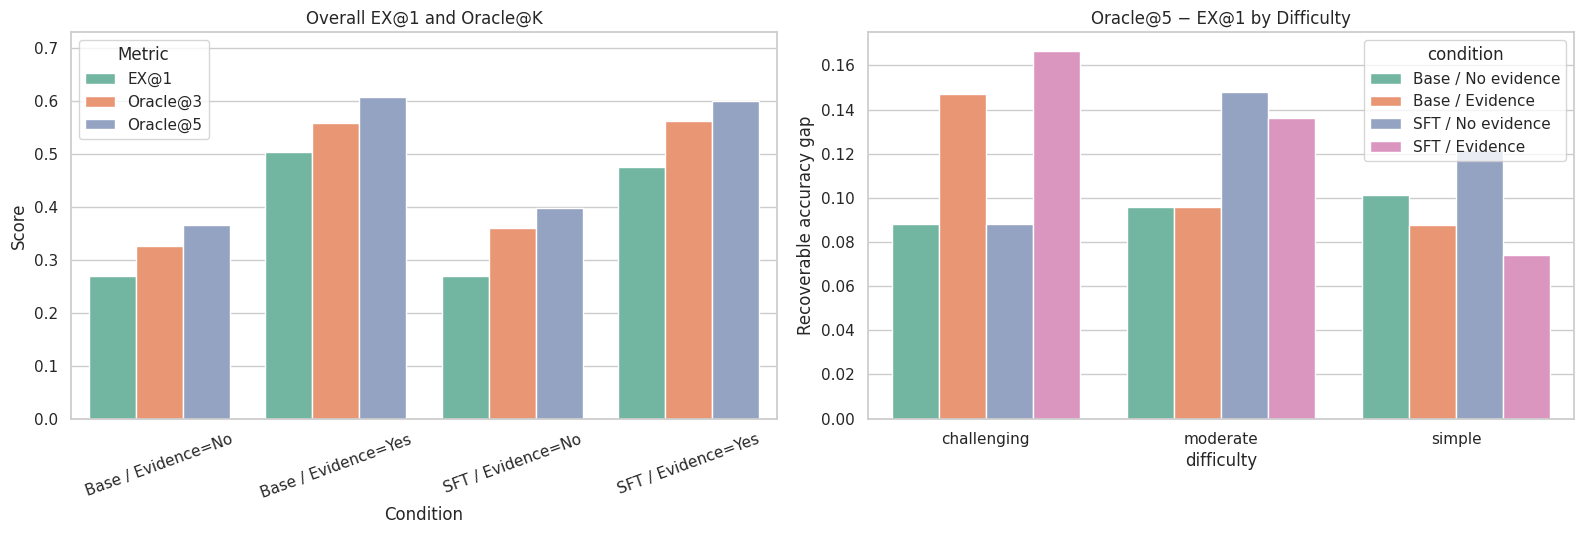

Saved chart: /content/drive/MyDrive/bird-text2sql-sft/results/minidev500_ex1_oracle3_oracle5_four_way/four_way_ex1_oracle_accuracy.png


In [ ]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

summary_long = summary_table.melt(
    id_vars=["Experiment", "Model", "Evidence"],
    value_vars=["EX@1", "Oracle@3", "Oracle@5"],
    var_name="Metric",
    value_name="Score",
)
summary_long["Condition"] = (
    summary_long["Model"] + " / Evidence=" + summary_long["Evidence"]
)
sns.barplot(
    data=summary_long,
    x="Condition",
    y="Score",
    hue="Metric",
    ax=axes[0],
    palette="Set2",
)
axes[0].set_ylim(0, min(1.0, max(0.1, summary_long["Score"].max() * 1.20)))
axes[0].set_title("Overall EX@1 and Oracle@K")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=difficulty_comparison,
    x="difficulty",
    y="oracle_gain_5_vs_1",
    hue="condition",
    ax=axes[1],
    palette="Set2",
)
axes[1].set_title("Oracle@5 − EX@1 by Difficulty")
axes[1].set_ylabel("Recoverable accuracy gap")

plt.tight_layout()
chart_path = PROJECT_DIR / "four_way_ex1_oracle_accuracy.png"
fig.savefig(chart_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved chart:", chart_path)


## 17. Inspect Paired EX@1 Changes and Oracle Recoveries

The first view preserves the original paired Base/SFT/Evidence error analysis at EX@1. The second view isolates questions where greedy decoding failed but one of the additional candidates succeeded.


In [ ]:
def inspect_pair_changes(effect_name, max_rows=10):
    control_label, treatment_label = PAIR_SPECS[effect_name]
    change_column = f"change_ex_at_1_{effect_name}"
    columns = [
        "position", "source_index", "db_id", "difficulty",
        "question", "evidence",
        f"predicted_sql_{control_label}",
        f"predicted_sql_{treatment_label}",
        "gold_sql", change_column,
    ]

    print(f"\n{effect_name} / EX@1: improved examples")
    display(four_way.loc[four_way[change_column] == "improved", columns].head(max_rows))
    print(f"{effect_name} / EX@1: regressed examples")
    display(four_way.loc[four_way[change_column] == "regressed", columns].head(max_rows))


for effect_name in PAIR_SPECS:
    inspect_pair_changes(effect_name, max_rows=10)


def inspect_oracle_recoveries(experiment_label, max_rows=10):
    result_df = RESULTS_BY_EXPERIMENT[experiment_label].copy()
    ex1 = bool_series(result_df["ex_at_1"])
    oracle5 = bool_series(result_df["oracle_at_5"])
    recovered = result_df.loc[(~ex1) & oracle5].copy()

    candidate_sql_columns = [
        f"candidate_{rank}_predicted_sql"
        for rank in range(1, NUM_CANDIDATES + 1)
    ]
    columns = [
        "position", "db_id", "difficulty", "question", "evidence",
        "oracle_hit_rank", *candidate_sql_columns, "gold_sql",
    ]
    print(
        f"\n{experiment_label}: {len(recovered)} examples recovered by "
        "Oracle@5 after EX@1 failed"
    )
    display(recovered[columns].head(max_rows))


for experiment_label in RESULTS_BY_EXPERIMENT:
    inspect_oracle_recoveries(experiment_label, max_rows=10)


## 18. Write the Final Comparison Summary and List All Result Files


In [ ]:
comparison_summary = {
    "dataset": {
        "id": HF_DATASET_ID,
        "revision": HF_REVISION,
        "split": HF_SPLIT,
        "size": int(len(four_way)),
        "unique_databases": int(four_way["db_id"].nunique()),
        "sha256": DATASET_SHA256,
    },
    "candidate_protocol": {
        "num_candidates": NUM_CANDIDATES,
        "candidate_1": "greedy; used for EX@1",
        "candidates_2_to_5": {
            "method": "seeded multinomial sampling",
            "temperature": SAMPLING_TEMPERATURE,
            "top_p": SAMPLING_TOP_P,
            "seed_rule": "SEED + position",
        },
        "oracle_at_k": "at least one execution-correct SQL among candidates 1..K",
    },
    "experiments": SUMMARIES_BY_EXPERIMENT,
    "paired_effects": paired_effects.to_dict(orient="records"),
    "interaction": interaction_summary.to_dict(orient="records"),
    "interpretation": {
        "primary_deployable_metric": "EX@1 from greedy candidate 1",
        "oracle_metrics": ["Oracle@3", "Oracle@5"],
        "oracle_warning": "Oracle@K assumes a perfect selector and is an upper bound, not deployable accuracy.",
        "paired_delta_definition": "treatment score - control score",
        "interaction_definition": "(SFT evidence effect) - (Base evidence effect)",
        "mcnemar_test": "exact two-sided binomial test on discordant paired outcomes",
        "bootstrap_ci": "paired 10000-sample percentile bootstrap",
    },
}
atomic_write_json(
    comparison_summary,
    PROJECT_DIR / "four_way_ex1_oracle_comparison_summary.json",
)

result_files = sorted(
    path for path in PROJECT_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in {".csv", ".json", ".jsonl", ".png"}
)

print("Evaluation complete. Result files:")
for path in result_files:
    print(f" - {path.name} ({path.stat().st_size / 1024:.1f} KB)")

print("\nMost important files:")
print(" - four_way_metric_summary.csv: EX@1, Oracle@3, and Oracle@5 for all four conditions")
print(" - four_way_ex1_oracle_comparison_summary.json: final machine-readable conclusions")
print(" - *_minidev500_results.csv: all five SQL candidates and execution outcomes per example")
print(" - *_all_candidates.json: compact five-candidate exports")
print(" - paired_effects_all_metrics.csv: paired effects for all three accuracy metrics")
print(" - four_way_by_difficulty.csv / four_way_by_database.csv: subgroup Oracle analysis")
print(" - four_way_per_example.csv: aligned four-condition metrics")


## Guide to Interpreting the Results

Review the results in this order:

1. **EX@1** is the execution accuracy of greedy candidate 1. Use it as the directly deployable single-output metric and compare it with the earlier notebook.
2. **Oracle@3** asks whether a perfect selector could find a correct SQL among candidates 1–3.
3. **Oracle@5** asks the same question among candidates 1–5.
4. **Oracle@5 − EX@1** measures the recoverable candidate-selection opportunity. A large gap means generation already contains useful alternatives; the next bottleneck is ranking or verification. A small gap means candidate generation itself needs improvement.
5. Compare Base and SFT at each metric. An SFT gain only in Oracle@5 suggests better candidate coverage without better first-choice ranking. A gain in EX@1 suggests the model's preferred answer improved.
6. Compare with/without evidence at a fixed model. This isolates whether evidence improves the first choice, candidate coverage, or both.
7. Inspect `oracle_hit_rank` and the Oracle recovery examples before building DPO or reranking data. These rows show which correct alternatives the current model already knows how to produce.
8. Use paired bootstrap confidence intervals and McNemar p-values to judge stability; do not treat the four runs as independent datasets.
9. Treat Oracle@K as an upper bound. To realize the gain, add a selector such as execution-guided filtering, self-consistency, a reward model, or a learned/rule-based SQL ranker evaluated without access to Gold answers.

Mini-Dev remains a public development set. Once these results influence the prompt, sampling settings, checkpoint, DPO pairs, or reranker, the 500 examples have become validation data and should not be presented as an untouched final test set.
